<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/1111ResumeJobmatching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install transformers datasets torch accelerate


In [5]:
pip install scikit-learn gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 38.2 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
# nlp
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB


from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [60]:
from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
import pandas as pd
import torch.nn.functional as F
import pdfplumber

In [8]:
from google.colab import files

In [9]:
# uploaded=files.upload()

In [10]:
import zipfile
with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall('resume_dataset')

In [11]:
# check the folder structure
import os
for  root,dirs,fs in os.walk('resume_dataset'):
  print(root, '->', fs[:3], f"...({len(fs)} files)" if len(fs) > 3 else "")

resume_dataset -> [] 
resume_dataset/Resume -> ['Resume.csv'] 
resume_dataset/data -> [] 
resume_dataset/data/data -> [] 
resume_dataset/data/data/BPO -> ['63158213.pdf', '30709029.pdf', '89512321.pdf'] ...(22 files)
resume_dataset/data/data/ADVOCATE -> ['26071861.pdf', '20272792.pdf', '37560528.pdf'] ...(118 files)
resume_dataset/data/data/SALES -> ['26425074.pdf', '28198029.pdf', '26994282.pdf'] ...(116 files)
resume_dataset/data/data/CONSTRUCTION -> ['19364677.pdf', '69764348.pdf', '22546476.pdf'] ...(112 files)
resume_dataset/data/data/HR -> ['24402267.pdf', '28808263.pdf', '91930382.pdf'] ...(110 files)
resume_dataset/data/data/APPAREL -> ['21807211.pdf', '56025640.pdf', '25543217.pdf'] ...(97 files)
resume_dataset/data/data/CHEF -> ['47603843.pdf', '10333299.pdf', '23841877.pdf'] ...(118 files)
resume_dataset/data/data/ACCOUNTANT -> ['15821633.pdf', '28939941.pdf', '27573855.pdf'] ...(118 files)
resume_dataset/data/data/HEALTHCARE -> ['33803142.pdf', '60624892.pdf', '24025053.pdf

In [12]:

resume_df=pd.read_csv('/content/resume_dataset/Resume/Resume.csv')


**EDA**

In [13]:
resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [14]:
print(resume_df.columns.tolist())

['ID', 'Resume_str', 'Resume_html', 'Category']


In [15]:
resume_df.shape

(2484, 4)

In [16]:
resume_df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [17]:
print(resume_df['Category'].value_counts())
print(resume_df.info())


Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str 

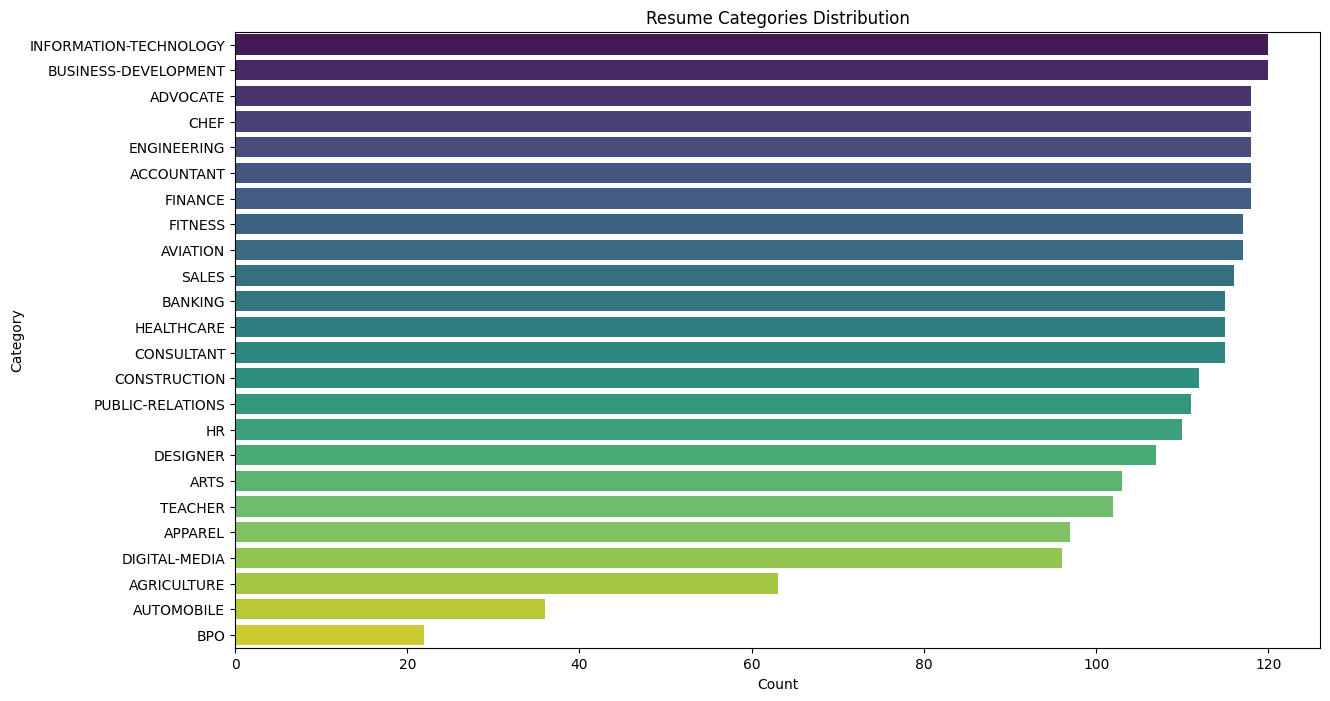

In [18]:
plt.figure(figsize=(14,8))

sns.countplot(
    y=resume_df['Category'],
    order=resume_df['Category'].value_counts().index,
    palette='viridis'
)

plt.title('Resume Categories Distribution')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

<Figure size 1400x800 with 0 Axes>

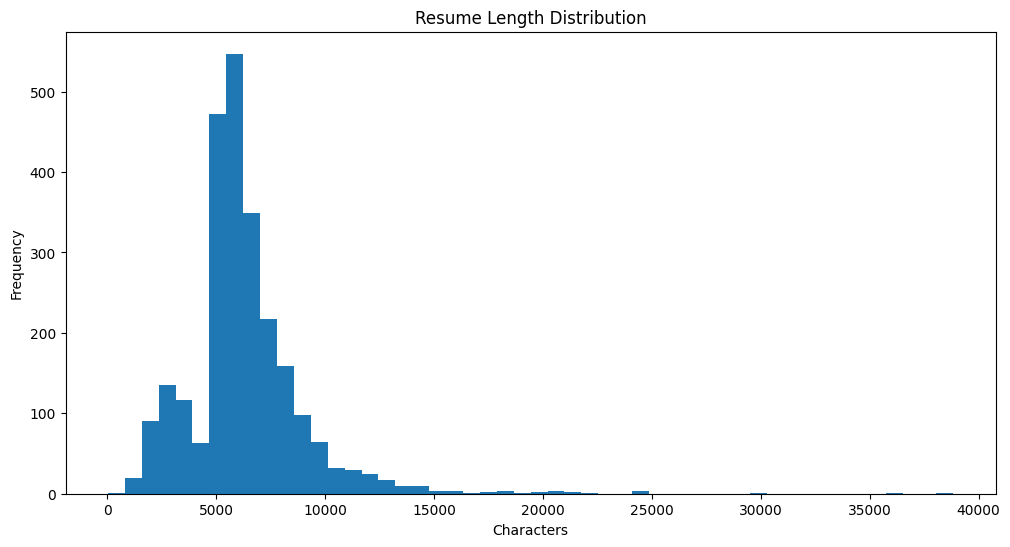

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: resume_length, dtype: float64


In [19]:
resume_df['resume_length'] = resume_df['Resume_str'].apply(len)

plt.figure(figsize=(14,8))


plt.figure(figsize=(12,6))
plt.hist(resume_df['resume_length'], bins=50)
plt.title('Resume Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()

print(resume_df['resume_length'].describe())

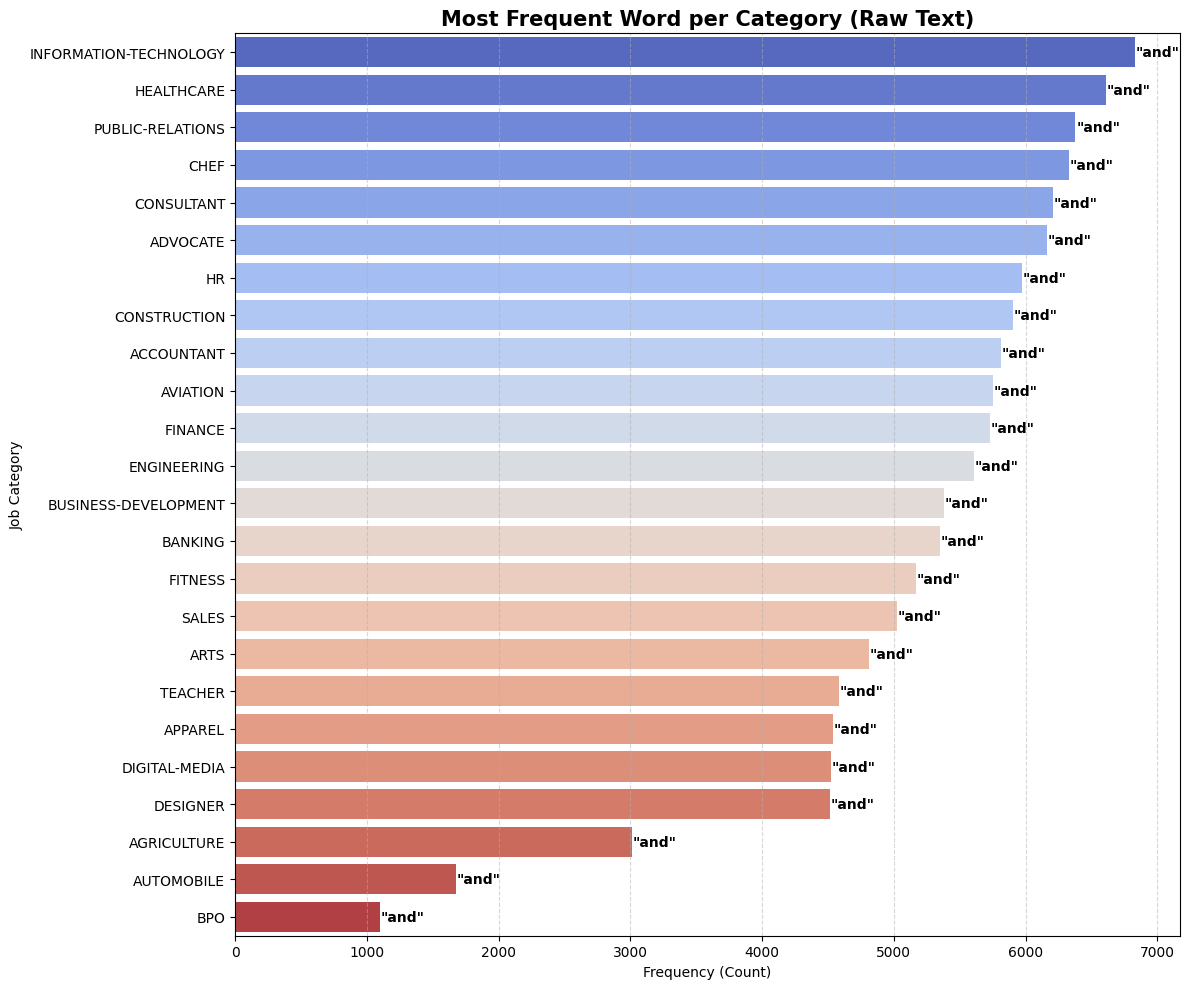

                  Category Top_Word  Count
2   INFORMATION-TECHNOLOGY      and   6827
6               HEALTHCARE      and   6607
20        PUBLIC-RELATIONS      and   6378
14                    CHEF      and   6332
11              CONSULTANT      and   6206
4                 ADVOCATE      and   6164
0                       HR      and   5974
19            CONSTRUCTION      and   5906
18              ACCOUNTANT      and   5816
23                AVIATION      and   5755
15                 FINANCE      and   5729
17             ENGINEERING      and   5607
5     BUSINESS-DEVELOPMENT      and   5380
21                 BANKING      and   5347
7                  FITNESS      and   5168
10                   SALES      and   5020
22                    ARTS      and   4812
3                  TEACHER      and   4581
16                 APPAREL      and   4541
12           DIGITAL-MEDIA      and   4520
1                 DESIGNER      and   4513
8              AGRICULTURE      and   3015
13         

In [20]:
from collections import Counter


# 1. Logic to find the most frequent word per category
results = []
categories = resume_df['Category'].unique()

for cat in categories:
    # Combine all raw text for this specific category
    raw_text = " ".join(resume_df[resume_df['Category'] == cat]['Resume_str'].astype(str)).lower().split()

    # Optional: Filter out words with 2 or fewer characters to avoid 'a', 'to', 'of'
    filtered_words = [w for w in raw_text if len(w) > 2 ]

    if filtered_words:
        top_word, count = Counter(filtered_words).most_common(1)[0]
        results.append({'Category': cat, 'Top_Word': top_word, 'Count': count})

top_words_df = pd.DataFrame(results).sort_values(by='Count', ascending=False)

# 2. Visualization
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='Count', y='Category', data=top_words_df, palette='coolwarm')

# 3. Annotate the bars with the actual word
for i, (count, word) in enumerate(zip(top_words_df['Count'], top_words_df['Top_Word'])):
    ax.text(count + 5, i, f'"{word}"', va='center', fontweight='bold', color='black')

plt.title('Most Frequent Word per Category (Raw Text)', fontsize=15, fontweight='bold')
plt.xlabel('Frequency (Count)')
plt.ylabel('Job Category')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Print the table for reference
print(top_words_df)

Text preprocessing

In [21]:
resume_df

,ID,Resume_str,Resume_html,Category,resume_length
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,5442
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,5572
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,7720
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,2855
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,9172
...,...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,5533
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION,7108
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,2020
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,5074


In [22]:
resume_df.drop(columns=['ID', 'Resume_html'], inplace=True)


In [23]:
# STOPWORDS = set(stopwords.words('english'))
# lemmatizer = WordNetLemmatizer()


# def clean_text(text):
#     # lower case
#     text=text.lower()

#     # remove url and links
#     text = re.sub(r'http\S+|www\S+', ' ', text)

#     # remove email
#     text = re.sub(r'\S+@\S+', ' ', text)

#     # remove special characters
#     text = re.sub(r'[^\w\s]', ' ', text)

#     # remove html
#     text = re.sub(r'<.*?>', ' ', text)

#     # remove numbers
#     text = re.sub(r'\d+', ' ', text)

#     # Keeps only alphabets and spaces
#     text = re.sub(r'[^a-zA-Z\s]', ' ', text)

#     # tokenization
#     tokens = word_tokenize(text)

#     # remove stopwords
#     # lemenization
#     # Only keeps words longer than 2 characters to filter out noise
#     tokens = [
#         lemmatizer.lemmatize(word)
#         for word in tokens
#         if word not in STOPWORDS and len(word) > 2
#     ]

#     # 9. Re-join and remove redundant whitespaces
#     text = ' '.join(tokens)
#     text = re.sub(r'\s+', ' ', text).strip()

#     return text
# print("cleaning text")
# resume_df['clean_text'] = resume_df['Resume_str'].apply(clean_text)
# # Inspect the transformation
# print(resume_df[['Resume_str', 'clean_text']].head())








Feature Enginnering

In [24]:
print(resume_df['Category'])

0             HR
1             HR
2             HR
3             HR
4             HR
          ...   
2479    AVIATION
2480    AVIATION
2481    AVIATION
2482    AVIATION
2483    AVIATION
Name: Category, Length: 2484, dtype: object


In [25]:
# tfidf=TfidfVectorizer(
#     max_features=5000,
#     min_df=2,
#     max_df=0.9,
#     ngram_range=(1,2),stop_words='english')

# X_tfidf=tfidf.fit_transform(resume_df['clean_text'])

# tfidf_ngram = TfidfVectorizer(
#     max_features=7000,
#     ngram_range=(1,2),
#     min_df=2,
#     max_df=0.9
# )
# X_ngram = tfidf_ngram.fit_transform(resume_df['clean_text'])


# tokenized_text = resume_df['clean_text'].apply(lambda x: x.split())

# # world2vec training
# word2vec_model=Word2Vec(
#     sentences=tokenized_text,
#     vector_size=100,
#     window=5,
#     min_count=1,
#     sg=0,
#     workers=4
# )

# le=LabelEncoder()
# y=le.fit_transform(resume_df['Category'])

# print("Label Encoder Classes:", le.classes_)

# print("\nWord2Vec Model Trained Successfully!")

# print("\nVector for word 'python':")
# print(word2vec_model.wv['python'][:10])

# print("\nWords similar to 'python':")
# print(word2vec_model.wv.most_similar('python')[:5])




Data Spliting(Train/test splt)

In [26]:
# X_train,X_test,y_train,y_test=train_test_split(
#     X_ngram,
#     y,
#     test_size=0.2,
#     random_state=42
# )
# print("X_train shape:", X_train.shape)
# print("X_test shape:", X_test.shape)
# print("y_train shape:", y_train.shape)
# print("y_test shape:", y_test.shape)


machine learning model

In [27]:
# svm_model=LinearSVC(
#     C=1,
#     class_weight='balanced',
#     random_state=42
# )
# log_model=LogisticRegression(
#     C=1,
#     class_weight='balanced',
#     random_state=42
# )
# nb_model=MultinomialNB()

model training

In [28]:
# print("Svm training")
# svm_model.fit(X_train,y_train)
# y_predict_svm=svm_model.predict(X_test)
# print(f"\nSVM Accuracy: {accuracy_score(y_test, y_predict_svm) * 100:.2f}%")
# print(classification_report(y_test, y_predict_svm, target_names=le.classes_))

# print("SVM finished")
# print("Logistic Regression training")
# log_model.fit(X_train,y_train)
# y_predict_log=log_model.predict(X_test)
# print(f"\nLogistic Regression Accuracy: {accuracy_score(y_test, y_predict_log) * 100:.2f}%")
# print(classification_report(y_test, y_predict_log, target_names=le.classes_))
# print("Logistic Regression finished")
# print("Naive Bayes training")
# nb_model.fit(X_train,y_train)
# y_predict_nb=nb_model.predict(X_test)
# print(f"\nNaive Bayes Accuracy: {accuracy_score(y_test, y_predict_nb) * 100:.2f}%")
# print("Naive Bayes finished")
# #classification report
# print(classification_report(y_test, y_predict_nb, target_names=le.classes_))


# **using transformer**

In [29]:
le = LabelEncoder()
resume_df['encoded_category'] = le.fit_transform(resume_df['Category'])

In [30]:
resume_df

,Resume_str,Category,resume_length,encoded_category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,5442,19
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,5572,19
2,HR DIRECTOR Summary Over 2...,HR,7720,19
3,HR SPECIALIST Summary Dedica...,HR,2855,19
4,HR MANAGER Skill Highlights ...,HR,9172,19
...,...,...,...,...
2479,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION,5533,6
2480,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION,7108,6
2481,GEEK SQUAD AGENT Professional...,AVIATION,2020,6
2482,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION,5074,6


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    resume_df['Resume_str'],
    resume_df['encoded_category'],
    test_size=0.2,
    random_state=42
)

In [32]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [33]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True
)

In [34]:
class ResumeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [35]:
train_dataset=ResumeDataset(train_encodings, y_train.tolist())
test_dataset=ResumeDataset(test_encodings, y_test.tolist())

In [36]:
model=DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(le.classes_)
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
)

In [38]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

In [39]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.925230
2,No log,0.629404
3,1.344049,0.608536


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=747, training_loss=1.062756692868479, metrics={'train_runtime': 368.3926, 'train_samples_per_second': 16.181, 'train_steps_per_second': 2.028, 'total_flos': 789947969052672.0, 'train_loss': 1.062756692868479, 'epoch': 3.0})

In [40]:
model.save_pretrained('./resume_classifier_model')
tokenizer.save_pretrained('./resume_classifier_model')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./resume_classifier_model/tokenizer_config.json',
 './resume_classifier_model/tokenizer.json')

In [41]:
predictions = trainer.predict(test_dataset)


In [42]:
y_pred = np.argmax(predictions.predictions, axis=1)


In [43]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8450704225352113


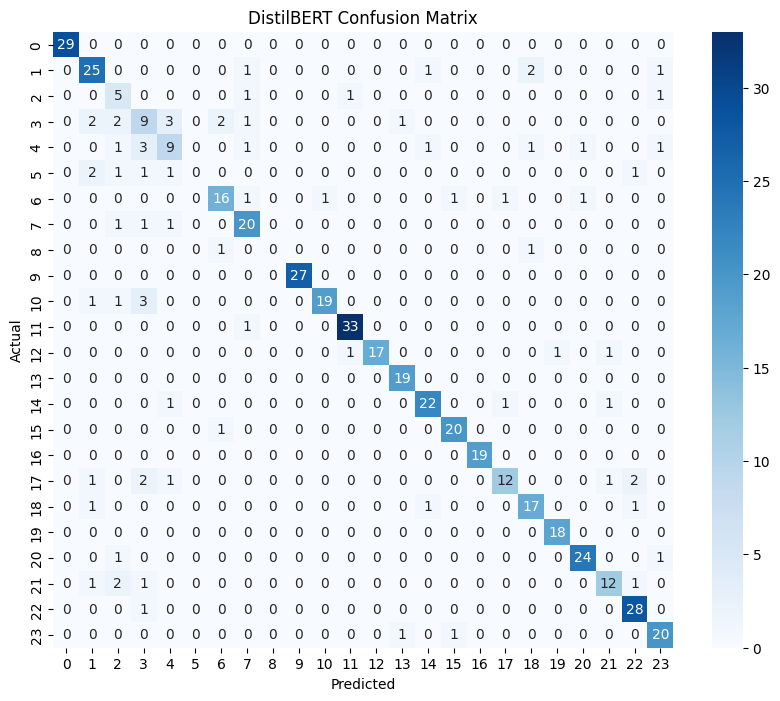

In [44]:
cm = confusion_matrix(y_test, y_pred)



import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.show()

In [45]:
misclassified=[]
for i in range(len(y_test)):
  actual=y_test.iloc[i]
  predicted=y_pred[i]

  if actual != predicted:
    misclassified.append({
        'Resume': X_test.iloc[i],
        'Actual': le.inverse_transform([actual])[0],
        'Predicted': le.inverse_transform([predicted])[0]
    })

In [46]:
misclassified_df=pd.DataFrame(misclassified)
misclassified_df.head(10)

,Resume,Actual,Predicted
0,SENIOR NETWORK SECURITY ENGINEER ...,ARTS,AGRICULTURE
1,AGENCY SALES RESOURCES Summary ...,AUTOMOBILE,SALES
2,INTERNSHIP Professional Ove...,BANKING,ARTS
3,SALES ASSOCIATE Summary I am...,SALES,APPAREL
4,SENIOR SPECIAL INVESTIGATOR ...,AUTOMOBILE,AGRICULTURE
5,CHIEF INNOVATION AND OUTREACH OFFICER...,PUBLIC-RELATIONS,AGRICULTURE
6,JAVA INTERN Career Overview ...,AVIATION,INFORMATION-TECHNOLOGY
7,COLLEGE ASSISTANT Summary P...,ARTS,HEALTHCARE
8,IT MANAGER Summary Ten years...,INFORMATION-TECHNOLOGY,AGRICULTURE
9,OWNER/ATTORNEY AND MEDIATOR ...,APPAREL,ADVOCATE


In [47]:
for i in range(5):
    print("===================================")
    print("Actual:", misclassified_df.iloc[i]['Actual'])
    print("Predicted:", misclassified_df.iloc[i]['Predicted'])
    print()
    print(misclassified_df.iloc[i]['Resume'][:1000])

Actual: ARTS
Predicted: AGRICULTURE

         SENIOR NETWORK SECURITY ENGINEER          https://www.linkedin.com/in/dilip-nr/         Professional Summary     Overall 7+ years of experience in Network and Security Engineering which includes strong hands-on experience with Palo Alto Firewalls, Cisco ASA Firewalls, Check Point Firewalls along with comprehensive working knowledge of Load Balancers, Wireless networking, VMware and Data center management. Areas of expertise include designing manageable networks, Threat prevention and Management, routing, switching, troubleshooting network performance issues and documentation. Overall 7+ years of experience in Network and Security Engineering which includes strong hands-on experience with Palo Alto Firewalls, Cisco ASA Firewalls, Check Point Firewalls along with comprehensive working knowledge of Load Balancers, Wireless networking, VMware and Data center management. Areas of expertise include designing manageable networks, Threat prevention

In [48]:
confusion_pairs=misclassified_df.groupby(['Actual', 'Predicted']).size().reset_index(name='Count')
confusion_pairs=confusion_pairs.sort_values(by='Count', ascending=False)
confusion_pairs.head(10)

,Actual,Predicted,Count
9,APPAREL,ARTS,3
14,ARTS,APPAREL,3
37,CHEF,APPAREL,3
7,APPAREL,ADVOCATE,2
8,APPAREL,AGRICULTURE,2
10,APPAREL,AVIATION,2
2,ADVOCATE,HEALTHCARE,2
47,FITNESS,APPAREL,2
50,FITNESS,SALES,2
57,PUBLIC-RELATIONS,AGRICULTURE,2


In [49]:
pip install pdfplumber


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 92.0 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [51]:
def predict_resume_category(text):
  inputs=tokenizer(
      text,
      truncation=True,
      padding=True,
      return_tensors='pt'
  )
  with torch.no_grad():
    outputs=model(**inputs)
  logits=outputs.logits
  predicted_class = torch.argmax(logits, dim=1).item()
  predicted_label = le.inverse_transform([predicted_class])[0]
  return predicted_label

In [61]:
device=torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

def predict_resume_with_confidence(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = F.softmax(outputs.logits, dim=1)

    confidence, predicted_class = torch.max(probabilities, dim=1)

    predicted_label = le.inverse_transform(
        [predicted_class.item()]
    )[0]

    return predicted_label, confidence.item()

In [62]:
import pdfplumber

def extract_text_from_pdf(pdf_path):

    text = ""

    with pdfplumber.open(pdf_path) as pdf:

        for page in pdf.pages:
            text += page.extract_text()

    return text

In [67]:
pdf_text = extract_text_from_pdf("/content/Black and White Minimalist Accountant Resume (2).pdf")

prediction, confidence = predict_resume_with_confident(pdf_text)

print("Predicted Category:", prediction)
print("Confidence:", round(confidence * 100, 2), "%")

Predicted Category: CONSTRUCTION
Confidence: 29.4 %
